In [2]:
import pandas as pd
from scipy.stats import spearmanr
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats as st
import scikit_posthocs as sp


# 1 Data Loading and Preparation

In [3]:
df = pd.read_csv("..\experiment\exp_20250721_145122\summary_per_run.csv")
df.head()


,agent,generator,run_id,total_steps,start_value,final_cumulative_reward,average_reward
0,Always Up Agent,Constant Generator,1,50,0.0,-50,-1.0
1,Always Up Agent,Constant Generator,2,50,0.0,-50,-1.0
2,Always Up Agent,Constant Generator,3,50,0.0,-50,-1.0
3,Always Up Agent,Linear Trend Generator,1,50,0.0,50,1.0
4,Always Up Agent,Linear Trend Generator,2,50,0.0,50,1.0


In [4]:
grouped = df.groupby(["agent", "generator"]).agg(
    mean_final_reward=("final_cumulative_reward", "mean"),
    std_final_reward=("final_cumulative_reward", "std"),
    mean_avg_reward=("average_reward", "mean"),
    std_avg_reward=("average_reward", "std"),
).reset_index()

grouped.sort_values(by="mean_final_reward", ascending=False)


,agent,generator,mean_final_reward,std_final_reward,mean_avg_reward,std_avg_reward
1,Always Up Agent,Linear Trend Generator,50.000000,0.000000,1.000000,0.000000
19,Frequency-Based Majority Agent,Linear Trend Generator,50.000000,0.000000,1.000000,0.000000
25,Repeat Last Movement Agent,Linear Trend Generator,48.000000,0.000000,0.960000,0.000000
28,Repeat Last Movement Agent,Periodic Trend Generator,44.000000,0.000000,0.880000,0.000000
31,SGD Classifier Agent,Linear Trend Generator,30.000000,0.000000,0.600000,0.000000
26,Repeat Last Movement Agent,Markov Regime-Switching Generator,29.333333,12.220202,0.586667,0.244404
34,SGD Classifier Agent,Periodic Trend Generator,26.000000,0.000000,0.520000,0.000000
2,Always Up Agent,Markov Regime-Switching Generator,22.666667,11.015141,0.453333,0.220303
20,Frequency-Based Majority Agent,Markov Regime-Switching Generator,18.000000,8.000000,0.360000,0.160000
3,Always Up Agent,Ornstein-Uhlenbeck Generator,16.666667,4.163332,0.333333,0.083267


# 2 Final Reward Analysis

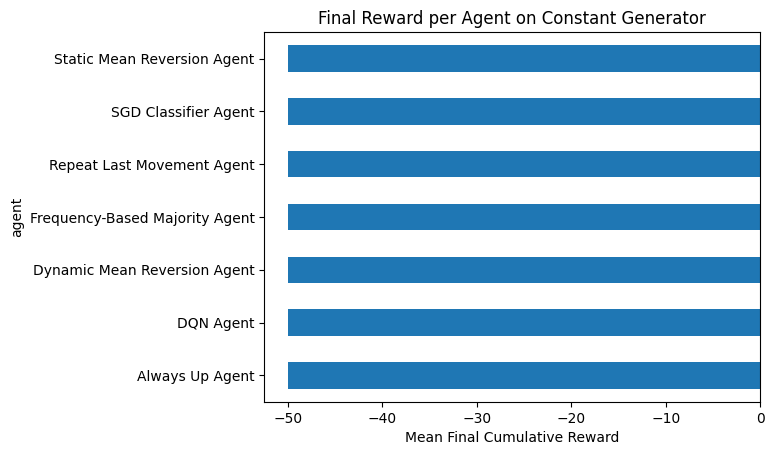

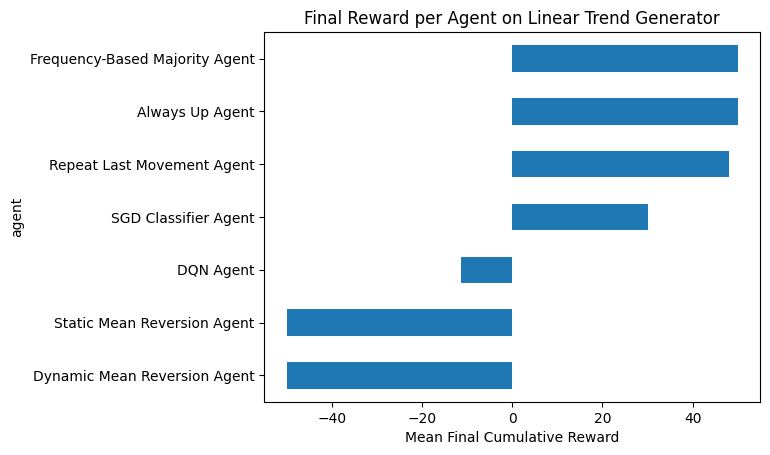

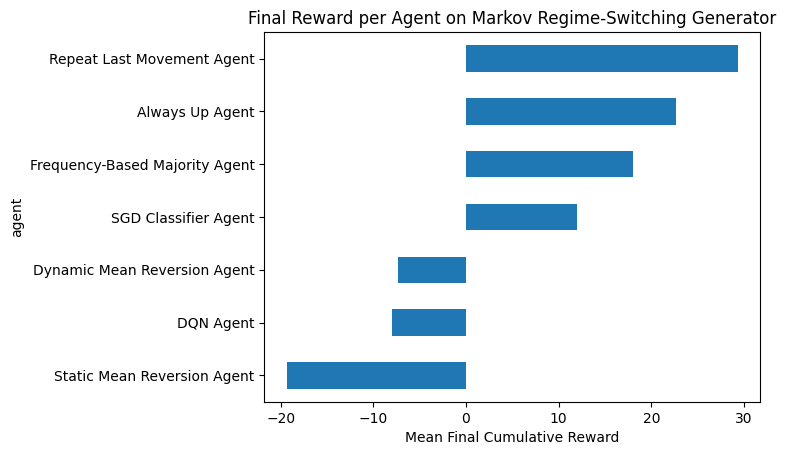

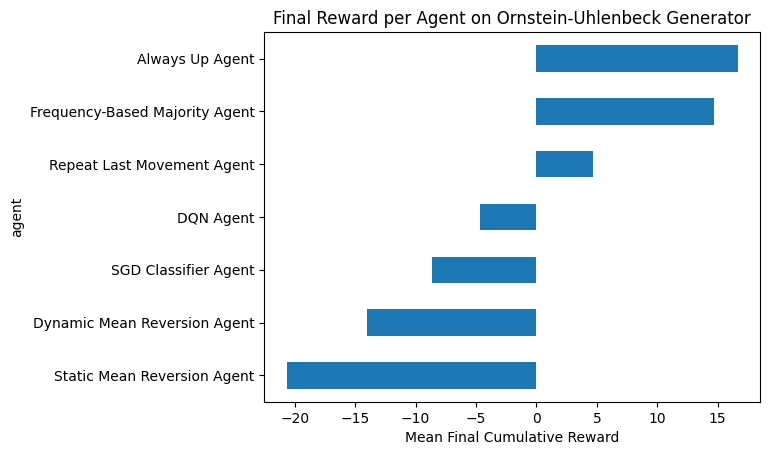

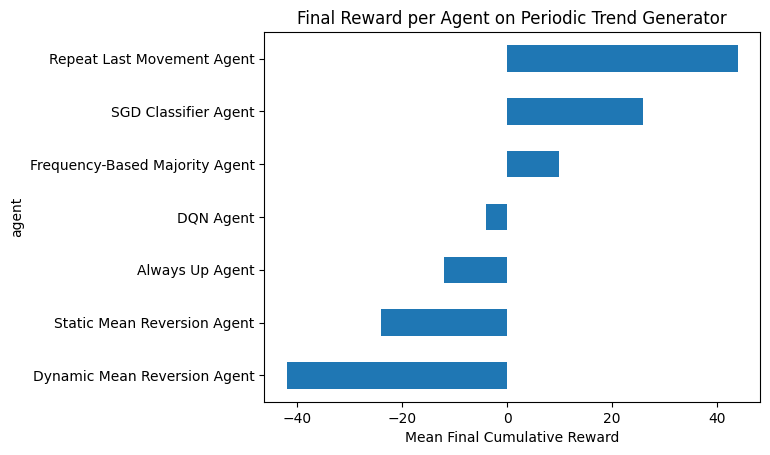

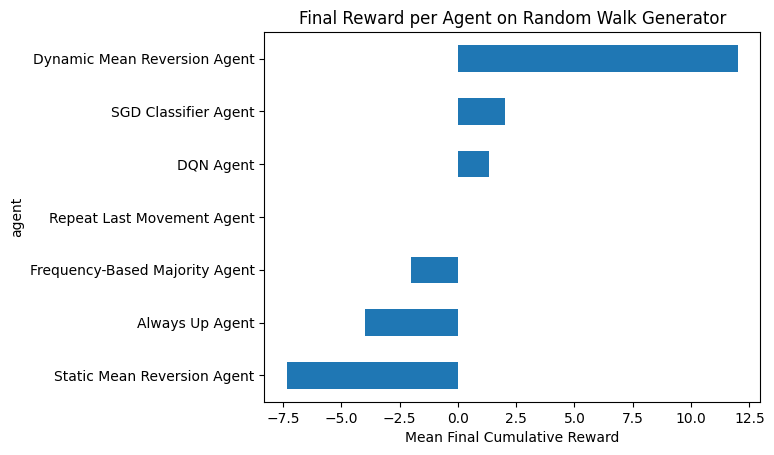

In [5]:

for generator in df["generator"].unique():
    subset = df[df["generator"] == generator]
    plt.figure()
    subset.groupby("agent")["final_cumulative_reward"].mean().sort_values().plot(kind="barh")
    plt.title(f"Final Reward per Agent on {generator}")
    plt.xlabel("Mean Final Cumulative Reward")
    plt.show()


# 3 Reward Distribution per Agent and Generator

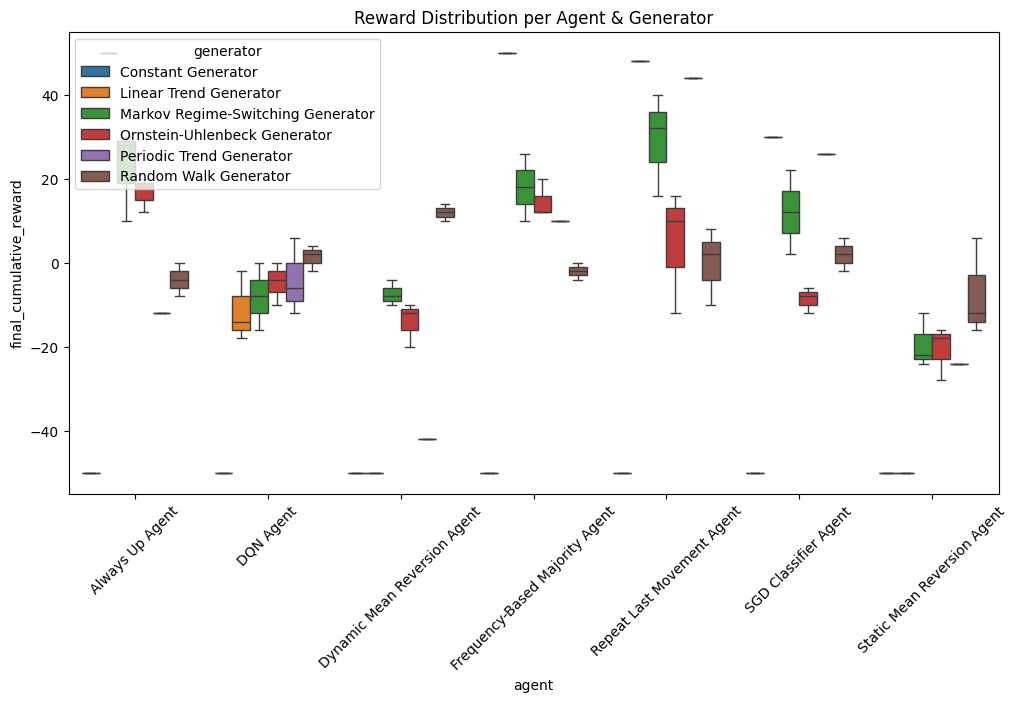

In [6]:

plt.figure(figsize=(12, 6))
sns.boxplot(x="agent", y="final_cumulative_reward", hue="generator", data=df)
plt.xticks(rotation=45)
plt.title("Reward Distribution per Agent & Generator")
plt.show()


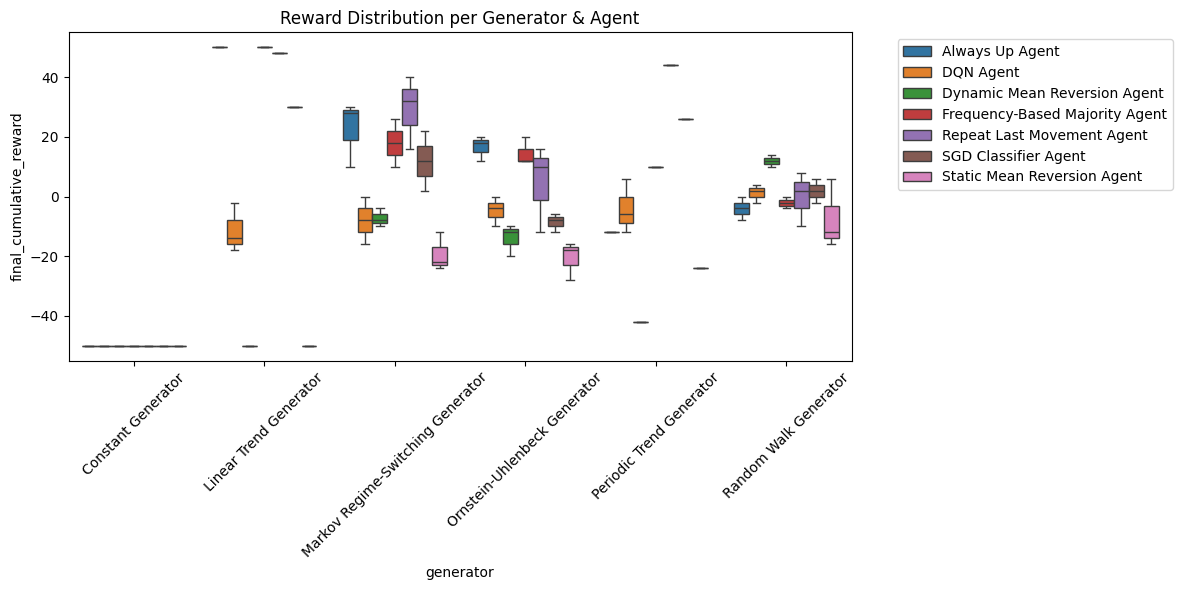

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="generator", y="final_cumulative_reward", hue="agent", data=df)
plt.xticks(rotation=45)
plt.title("Reward Distribution per Generator & Agent")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4 Heat Map of Agent-Generator Combinations

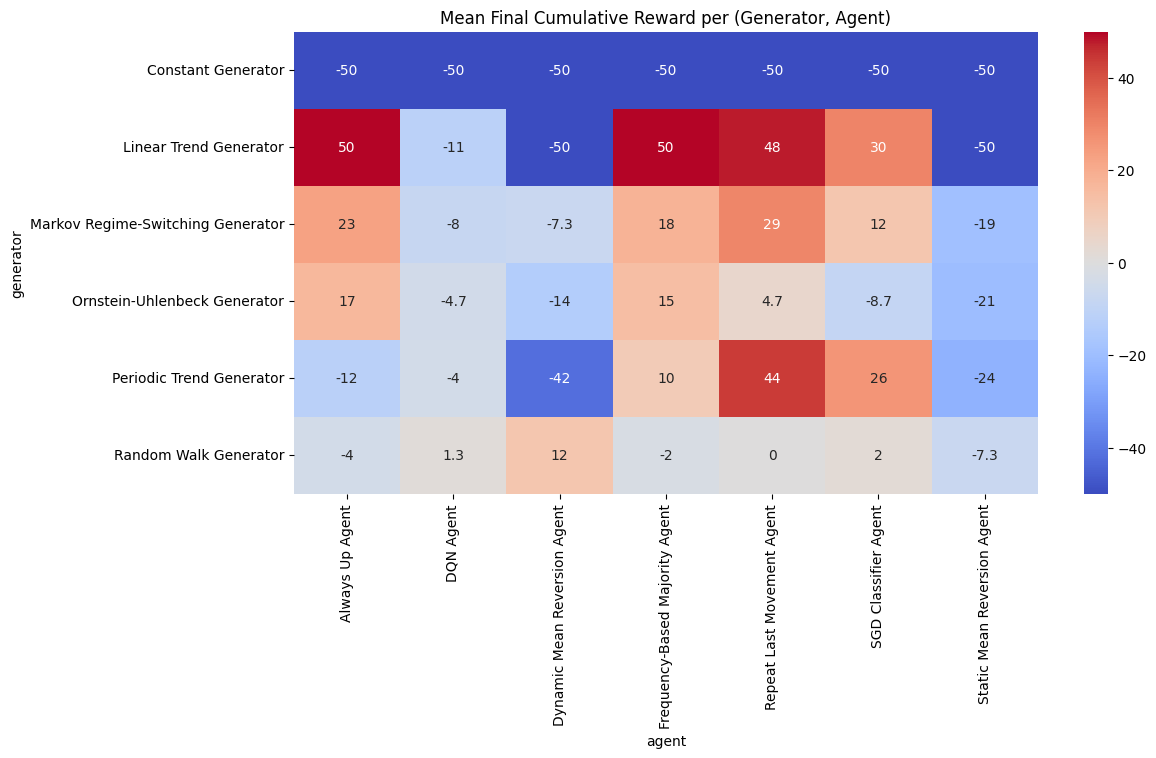

In [8]:
pivot_table = df.pivot_table(
    index="generator",
    columns="agent",
    values="final_cumulative_reward",
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, cmap="coolwarm", center=0)
plt.title("Mean Final Cumulative Reward per (Generator, Agent)")
plt.show()


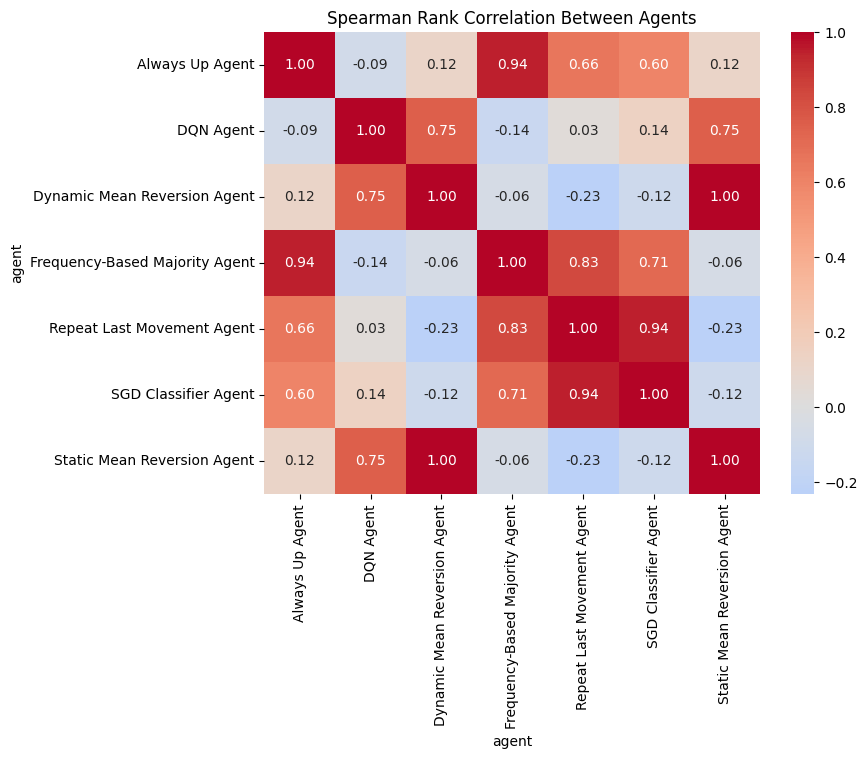

In [9]:
# Transpose so agents are rows, generators are columns
pivot_transposed = pivot_table.T

# Calculate Spearman correlation between agents
corr_matrix, p_values = spearmanr(pivot_transposed, axis=1)

# Convert to DataFrame for readability
agent_names = pivot_transposed.index
corr_df = pd.DataFrame(corr_matrix, index=agent_names, columns=agent_names)


plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Spearman Rank Correlation Between Agents")
plt.show();

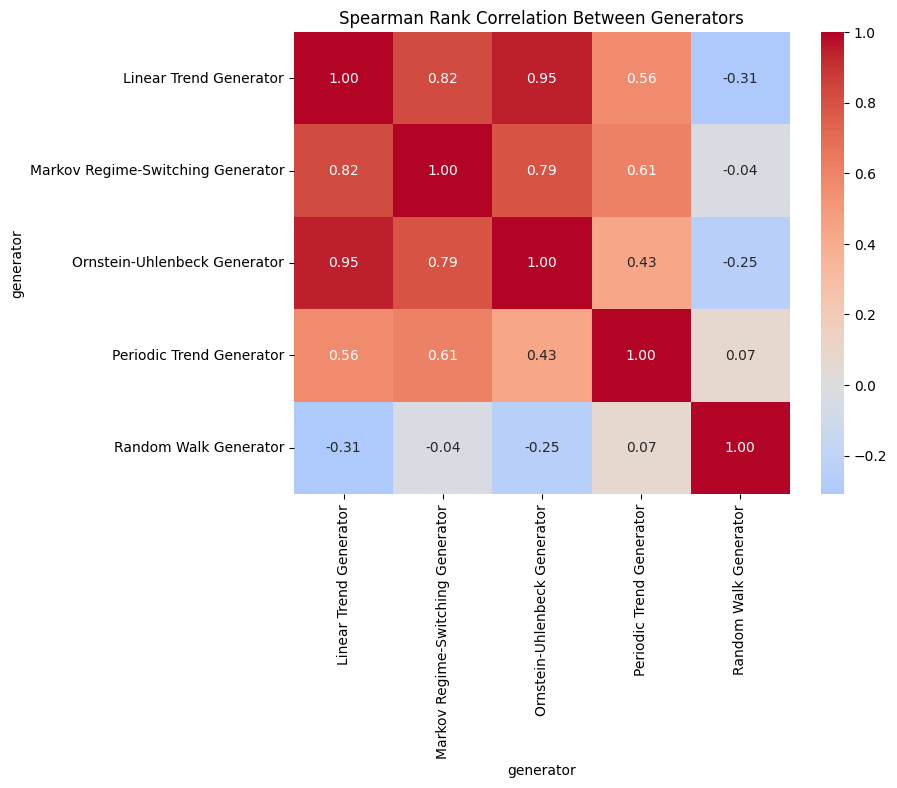

In [10]:
# Filter out constant rows before correlation
non_constant_rows = pivot_table.loc[pivot_table.var(axis=1) > 0]
corr_matrix_gens, _ = spearmanr(non_constant_rows, axis=1)
corr_df_gens = pd.DataFrame(corr_matrix_gens, index=non_constant_rows.index, columns=non_constant_rows.index)

# Plot only if matrix is non-empty
if not corr_df_gens.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_df_gens, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Spearman Rank Correlation Between Generators")
    plt.show()
else:
    print("No variable generators for correlation analysis.")


In [11]:
agent_generator_table = pivot_table.T.copy()
agent_generator_table["Mean Across Generators"] = agent_generator_table.mean(axis=1)
agent_generator_table

generator,Constant Generator,Linear Trend Generator,Markov Regime-Switching Generator,Ornstein-Uhlenbeck Generator,Periodic Trend Generator,Random Walk Generator,Mean Across Generators
agent,,,,,,,
Always Up Agent,-50.0,50.000000,22.666667,16.666667,-12.0,-4.000000,3.888889
DQN Agent,-50.0,-11.333333,-8.000000,-4.666667,-4.0,1.333333,-12.777778
Dynamic Mean Reversion Agent,-50.0,-50.000000,-7.333333,-14.000000,-42.0,12.000000,-25.222222
Frequency-Based Majority Agent,-50.0,50.000000,18.000000,14.666667,10.0,-2.000000,6.777778
Repeat Last Movement Agent,-50.0,48.000000,29.333333,4.666667,44.0,0.000000,12.666667
SGD Classifier Agent,-50.0,30.000000,12.000000,-8.666667,26.0,2.000000,1.888889
Static Mean Reversion Agent,-50.0,-50.000000,-19.333333,-20.666667,-24.0,-7.333333,-28.555556


# 4 Statistical Significance Testing

In [12]:
df

,agent,generator,run_id,total_steps,start_value,final_cumulative_reward,average_reward
0,Always Up Agent,Constant Generator,1,50,0.0,-50,-1.00
1,Always Up Agent,Constant Generator,2,50,0.0,-50,-1.00
2,Always Up Agent,Constant Generator,3,50,0.0,-50,-1.00
3,Always Up Agent,Linear Trend Generator,1,50,0.0,50,1.00
4,Always Up Agent,Linear Trend Generator,2,50,0.0,50,1.00
...,...,...,...,...,...,...,...
121,Static Mean Reversion Agent,Periodic Trend Generator,2,50,0.0,-24,-0.48
122,Static Mean Reversion Agent,Periodic Trend Generator,3,50,0.0,-24,-0.48
123,Static Mean Reversion Agent,Random Walk Generator,1,50,0.0,-16,-0.32
124,Static Mean Reversion Agent,Random Walk Generator,2,50,0.0,6,0.12


In [13]:
def compute_ci(data, confidence=0.95):
    mean = data.mean()
    sem = st.sem(data)
    ci_range = sem * st.t.ppf((1 + confidence) / 2., len(data) - 1)
    return pd.Series({'mean': mean, 'ci_lower': mean - ci_range, 'ci_upper': mean + ci_range})

# Apply groupby and expand into columns
ci_df = df.groupby(["agent", "generator"])["final_cumulative_reward"].apply(compute_ci).reset_index()


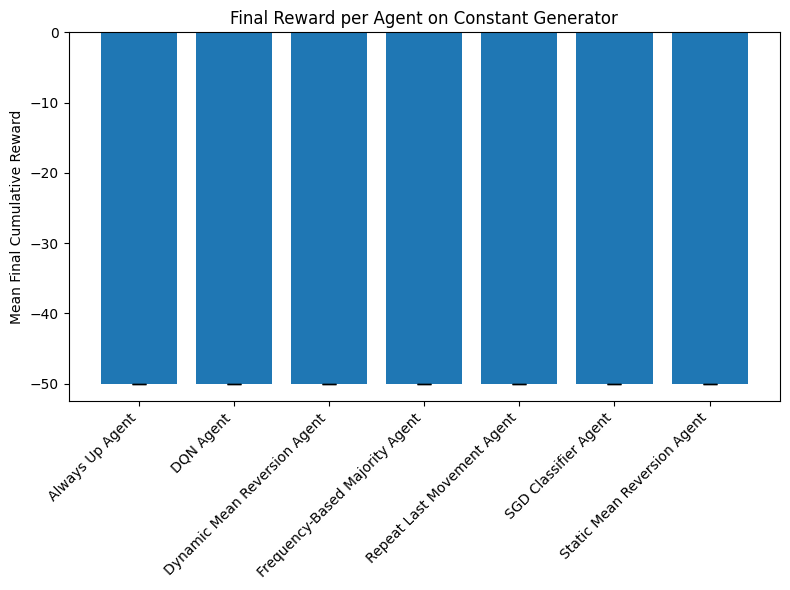

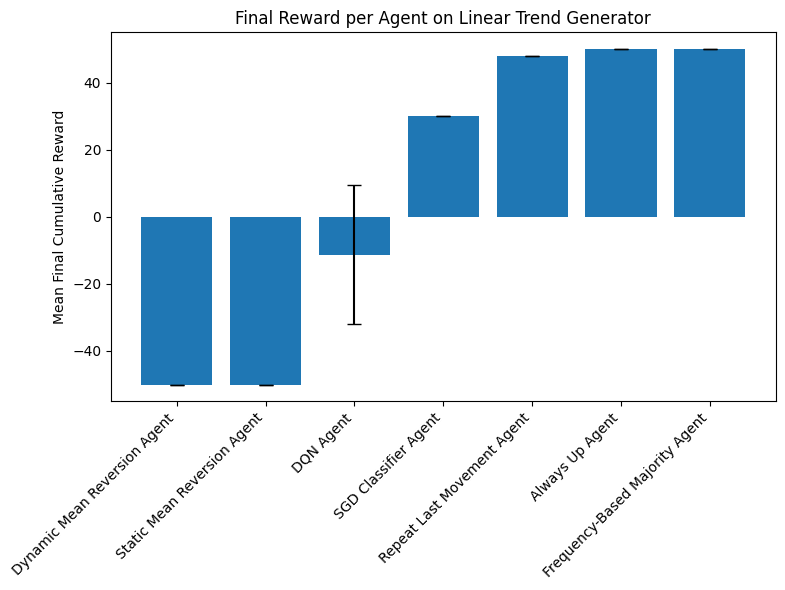

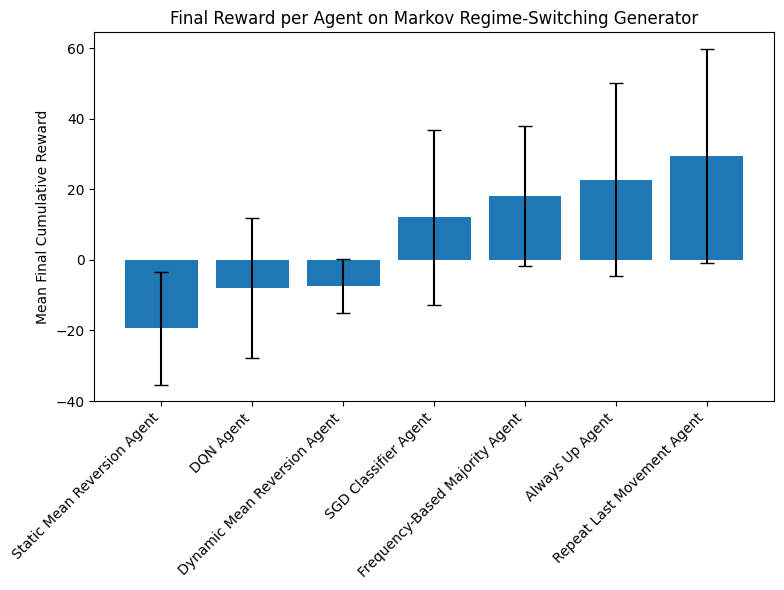

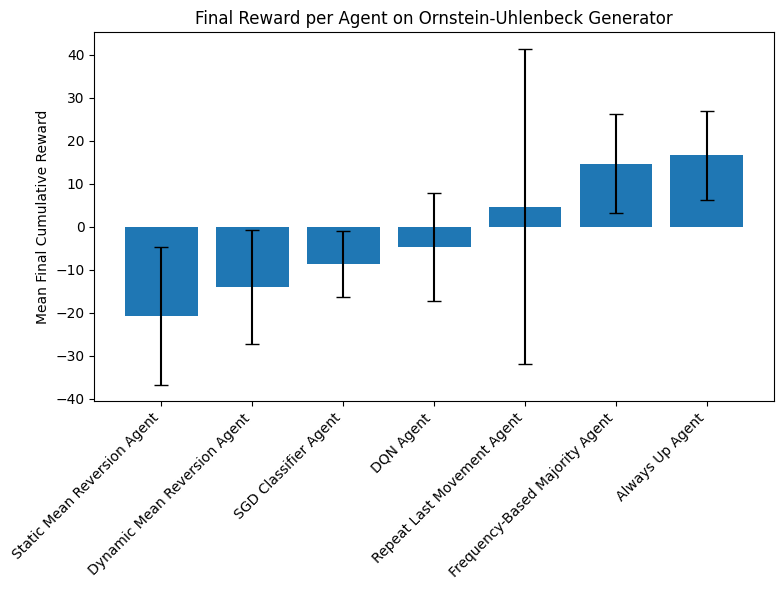

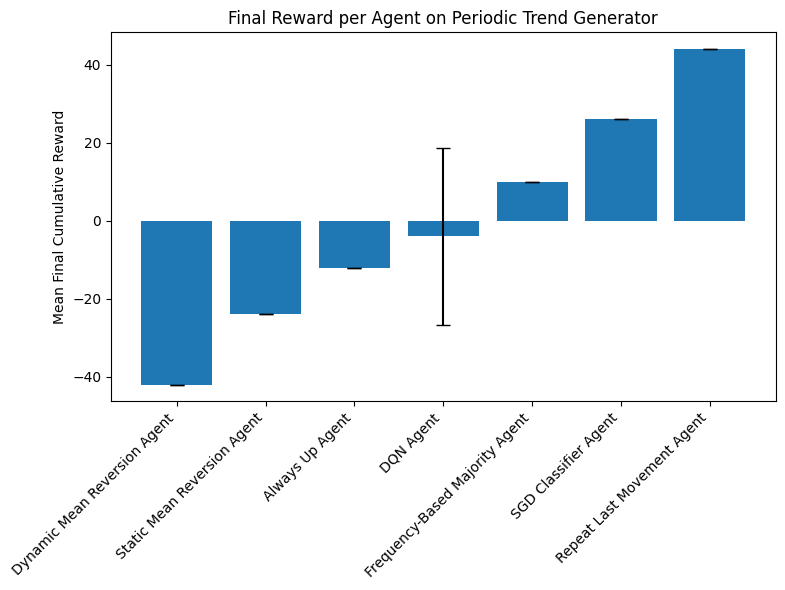

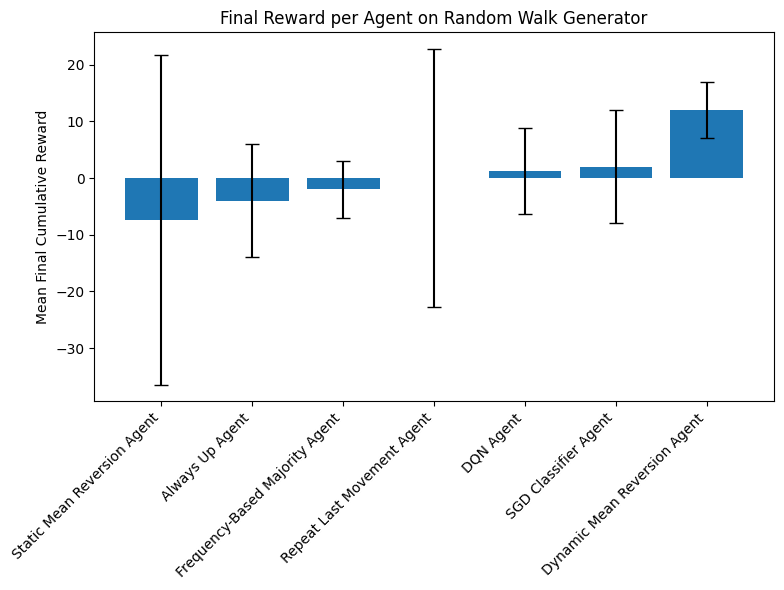

In [14]:
for generator in df["generator"].unique():
    subset_ci = ci_df[ci_df["generator"] == generator].pivot(index="agent", columns="level_2", values="final_cumulative_reward").reset_index()
    subset_ci_sorted = subset_ci.sort_values("mean")
    
    plt.figure(figsize=(8, 6))
    plt.bar(subset_ci_sorted["agent"], subset_ci_sorted["mean"], 
            yerr=[subset_ci_sorted["mean"] - subset_ci_sorted["ci_lower"], 
                  subset_ci_sorted["ci_upper"] - subset_ci_sorted["mean"]],
            capsize=5)
    plt.title(f"Final Reward per Agent on {generator}")
    plt.ylabel("Mean Final Cumulative Reward")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [15]:
from scipy.stats import kruskal

for generator in df["generator"].unique():
    subset = df[df["generator"] == generator]
    groups = [group["final_cumulative_reward"].values for _, group in subset.groupby("agent")]
    
    # Check if all groups have constant identical values
    if all(len(set(g)) == 1 for g in groups):
        print(f"{generator}: Skipped (all groups identical)")
        continue
    
    stat, p = kruskal(*groups)
    print(f"{generator}: Kruskal-Wallis H = {stat:.2f}, p = {p:.4f}")


Constant Generator: Skipped (all groups identical)
Linear Trend Generator: Kruskal-Wallis H = 19.95, p = 0.0028
Markov Regime-Switching Generator: Kruskal-Wallis H = 16.81, p = 0.0100
Ornstein-Uhlenbeck Generator: Kruskal-Wallis H = 16.08, p = 0.0133
Periodic Trend Generator: Kruskal-Wallis H = 19.83, p = 0.0030
Random Walk Generator: Kruskal-Wallis H = 10.39, p = 0.1092


c:\Users\JanderM\AppData\Local\anaconda3\envs\pred-bet-game\lib\site-packages\scikit_posthocs\_posthocs.py:366: RuntimeWarning: invalid value encountered in scalar divide
  z_value = diff / np.sqrt((A - x_ties) * B)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


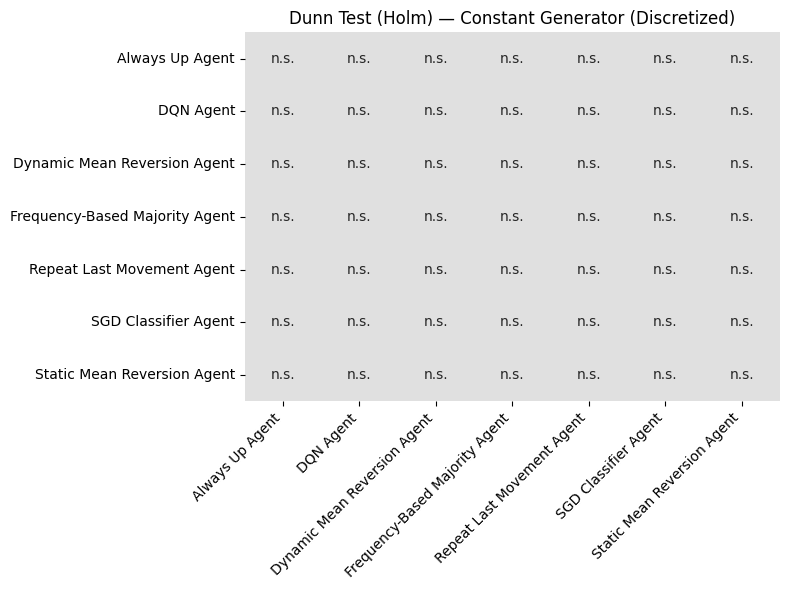

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


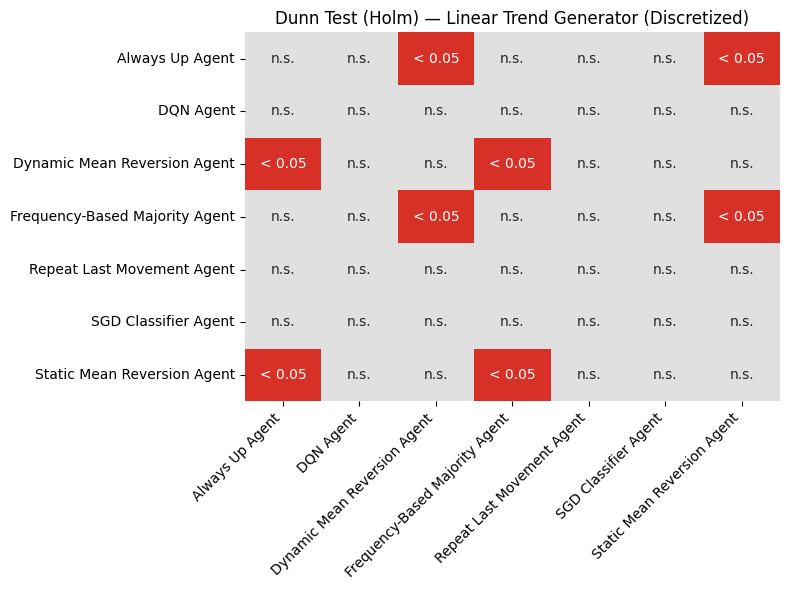

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


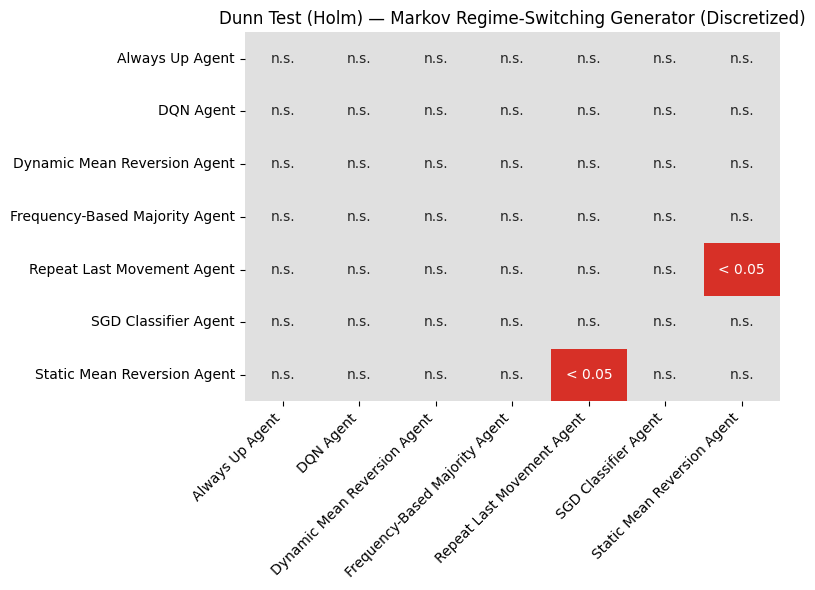

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


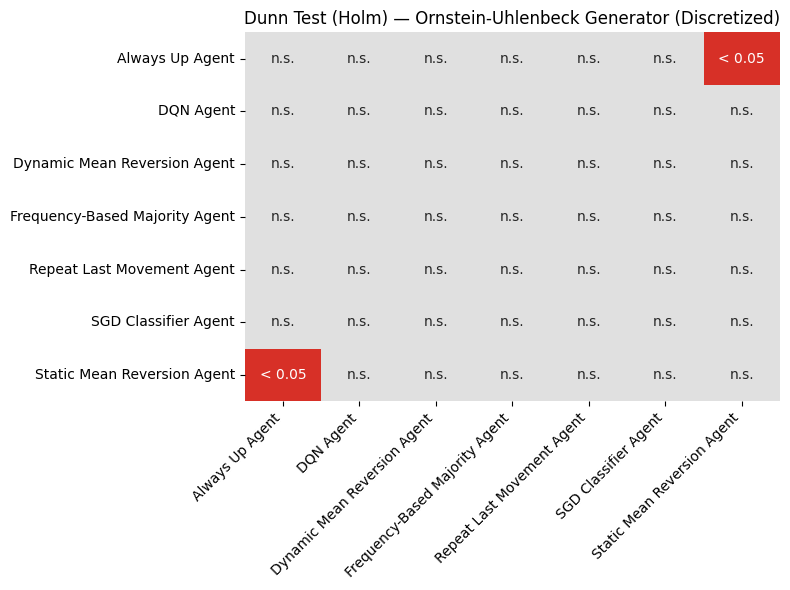

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


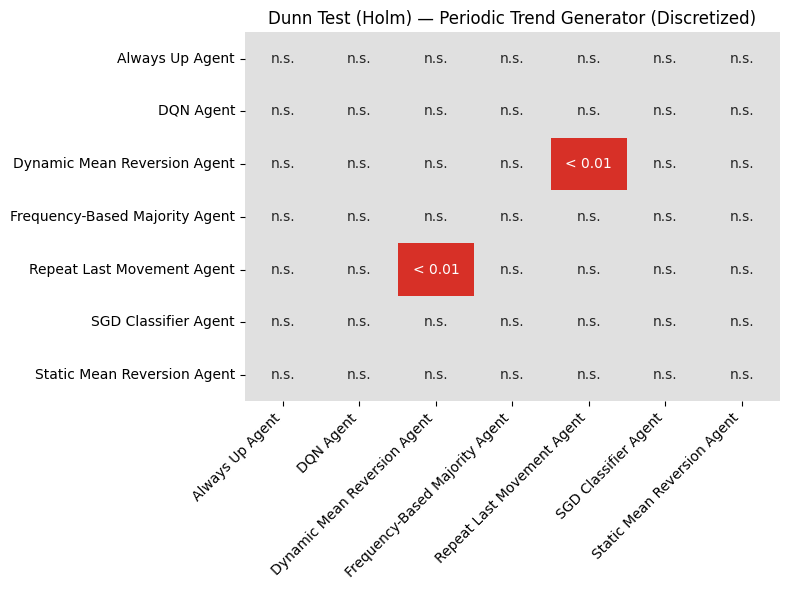

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


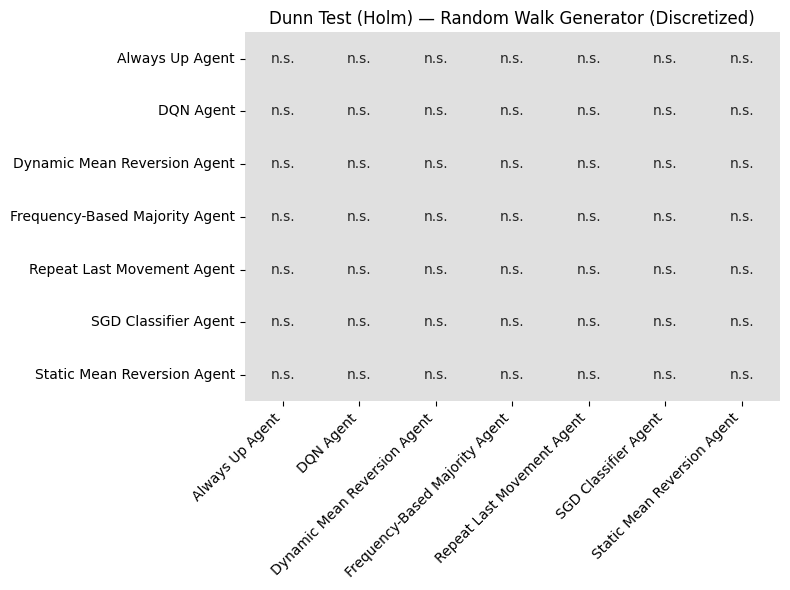

In [16]:


# Mapping categories to numeric values for plotting
pval_bins = {
    "< 0.001": 3,
    "< 0.01": 2,
    "< 0.05": 1,
    "n.s.": 0
}

# Color palette for the bins
palette = {
    3: "#d73027",  # strong red
    2: "#fc8d59",  # light red
    1: "#fee090",  # yellow
    0: "#e0e0e0"   # gray
}

def discretize_pval_num(p):
    if p < 0.001:
        return 3
    elif p < 0.01:
        return 2
    elif p < 0.05:
        return 1
    else:
        return 0

def discretize_pval_label(p):
    if p < 0.001:
        return "< 0.001"
    elif p < 0.01:
        return "< 0.01"
    elif p < 0.05:
        return "< 0.05"
    else:
        return "n.s."

for generator in df["generator"].unique():
    subset = df[df["generator"] == generator]
    dunn = sp.posthoc_dunn(subset, val_col='final_cumulative_reward', group_col='agent', p_adjust='holm')
    
    dunn_discrete = dunn.applymap(discretize_pval_num)
    dunn_labels = dunn.applymap(discretize_pval_label)

    plt.figure(figsize=(8, 6))
    sns.heatmap(dunn_discrete, annot=dunn_labels, fmt='', cmap=[palette[k] for k in sorted(palette.keys())], cbar=False)
    plt.title(f"Dunn Test (Holm) — {generator} (Discretized)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# 5 Convergence Analysis

In [17]:
convergence_df = pd.read_csv("C:/Users/JanderM/OneDrive - University of Twente/Documents/Github Repos/WP3_eXplainable_and_Fair_AI/IRP1/Code/predictability_betting_game/code/experiment/exp_20250718_160130/convergence_per_step.csv")
convergence_df

,agent,generator,run_id,step,cumulative_reward
0,Always Up Agent,Constant Generator,1,1,-1.0
1,Always Up Agent,Constant Generator,1,2,-2.0
2,Always Up Agent,Constant Generator,1,3,-3.0
3,Always Up Agent,Constant Generator,1,4,-4.0
4,Always Up Agent,Constant Generator,1,5,-5.0
...,...,...,...,...,...
34999995,Static Mean Reversion Agent,Random Walk Generator,100,9996,-48.0
34999996,Static Mean Reversion Agent,Random Walk Generator,100,9997,-49.0
34999997,Static Mean Reversion Agent,Random Walk Generator,100,9998,-50.0
34999998,Static Mean Reversion Agent,Random Walk Generator,100,9999,-51.0


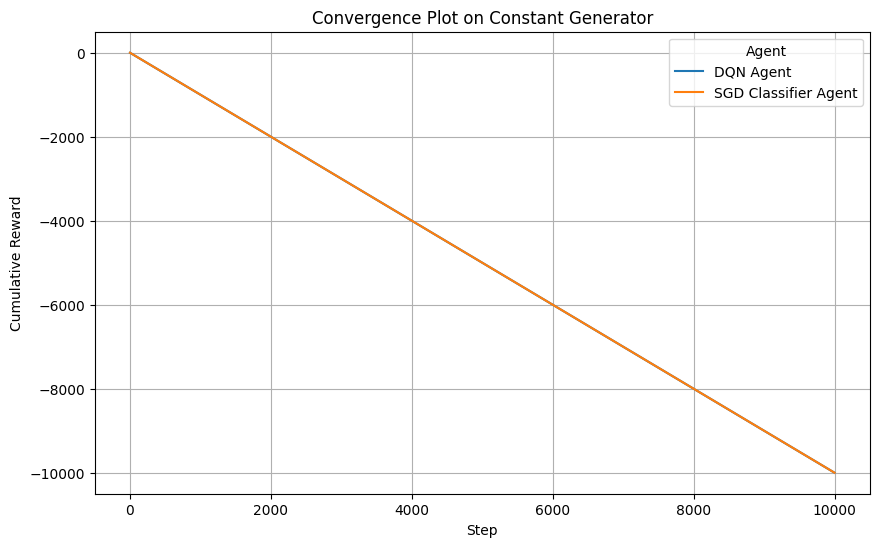

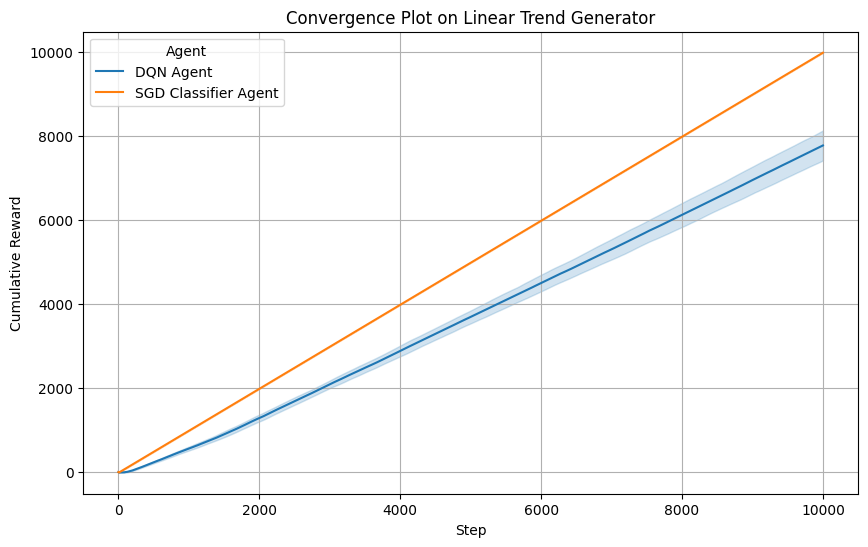

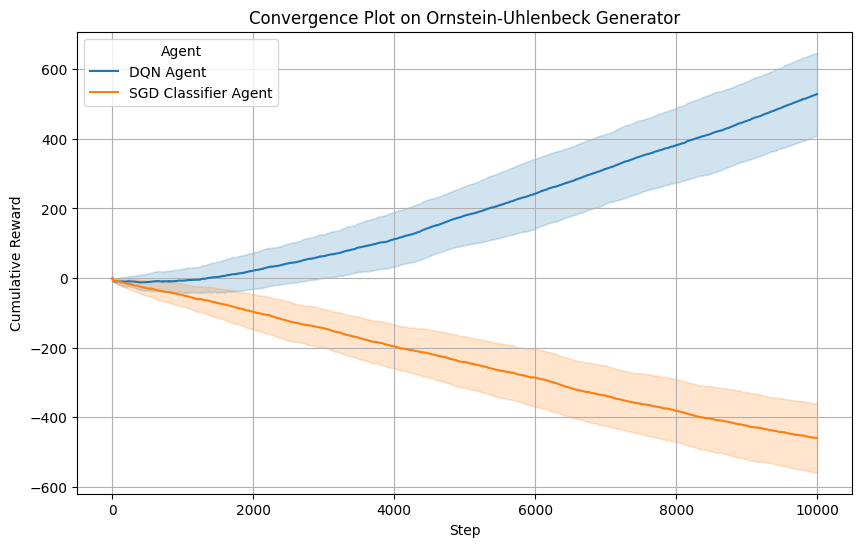

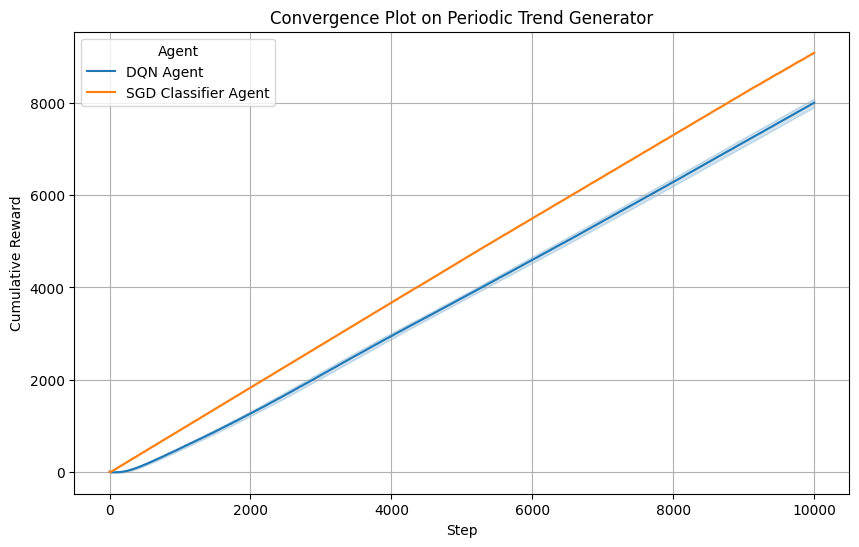

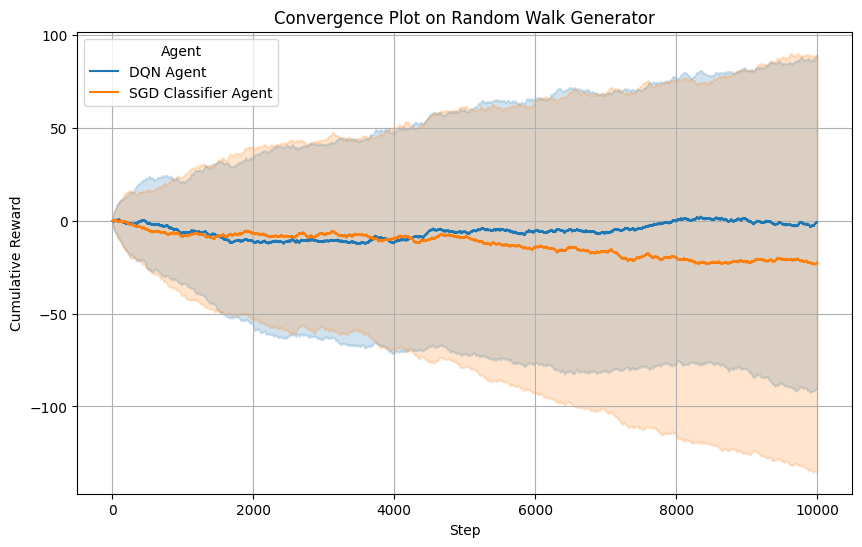

In [18]:

# Assuming your data is in df_convergence
# Filter for DQN and SGD agents only
agents_of_interest = ["DQN Agent", "SGD Classifier Agent"]
df_plot = convergence_df[convergence_df["agent"].isin(agents_of_interest)]

# Loop over generators
for generator in df_plot["generator"].unique():
    plt.figure(figsize=(10, 6))
    subset = df_plot[df_plot["generator"] == generator]

    sns.lineplot(
        data=subset,
        x="step",
        y="cumulative_reward",
        hue="agent",
        errorbar="sd",  # Shaded area = standard deviation across runs
        estimator="mean"
    )

    plt.title(f"Convergence Plot on {generator}")
    plt.xlabel("Step")
    plt.ylabel("Cumulative Reward")
    plt.legend(title="Agent")
    plt.grid(True)
    plt.show()
